In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

import pandas as pd 
df = pd.read_csv("ecommerce_dataset.csv")

In [2]:
df.head()


,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0


In [3]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [4]:
df = df.drop(["Latitude", "Longtitude"], axis=1)

df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


In [5]:
df = df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
})

df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


In [6]:
df.duplicated().sum()

np.int64(6)

In [7]:
df = df.drop_duplicates()

df.shape

(500, 12)

In [8]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

In [9]:
df["total"] = df["total"].fillna(df["total"].median())

In [10]:
#1 Exploratory Data Analysis

top_products = df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)

top_products

product
Watch         256
Mobile        230
Headphones    227
Bag           189
Shoes         188
Name: quantity, dtype: int64

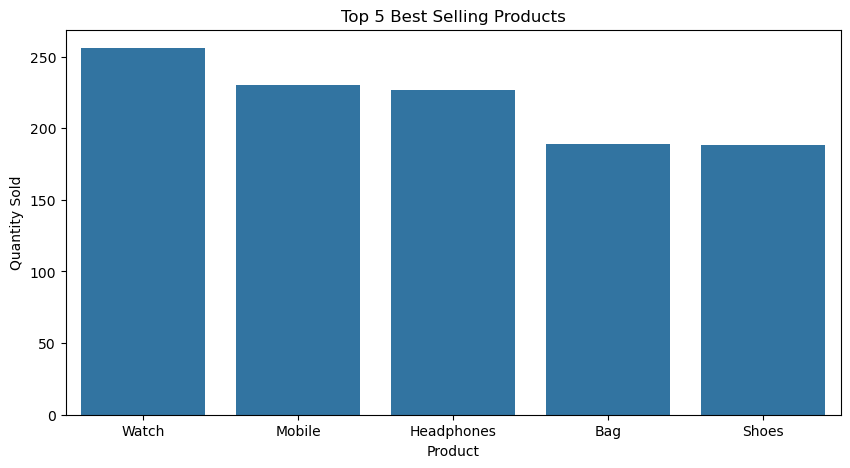

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(x=top_products.index, y=top_products.values)

plt.title("Top 5 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

In [12]:
#2. Payment Method Distribution

payment = df["payment_method"].value_counts()

payment

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

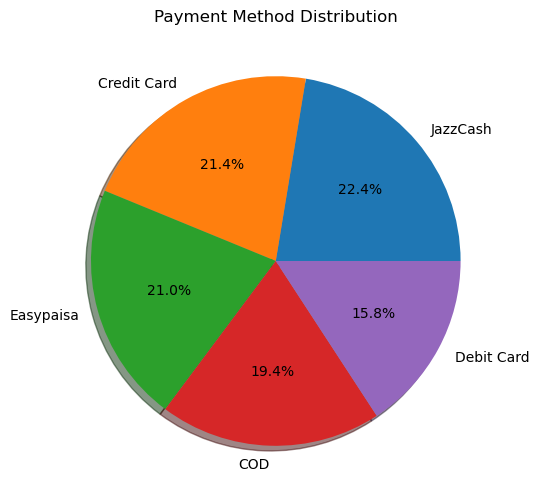

In [13]:
plt.figure(figsize=(8,6))

plt.pie(payment.values, labels=payment.index, autopct='%1.1f%%', shadow=True)

plt.title("Payment Method Distribution")

plt.show()

In [14]:
#3. Month-wise Sales

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = df.groupby("Month")["total"].sum().reindex(month_order)

monthly_sales

Month
January      6238414.59
February     5545040.22
March        6711119.66
April        6275753.74
May          5909845.92
June         2860920.11
July         2688475.62
August       2557288.54
September    2515916.08
October      3139444.82
November     2805153.37
December     3952563.75
Name: total, dtype: float64

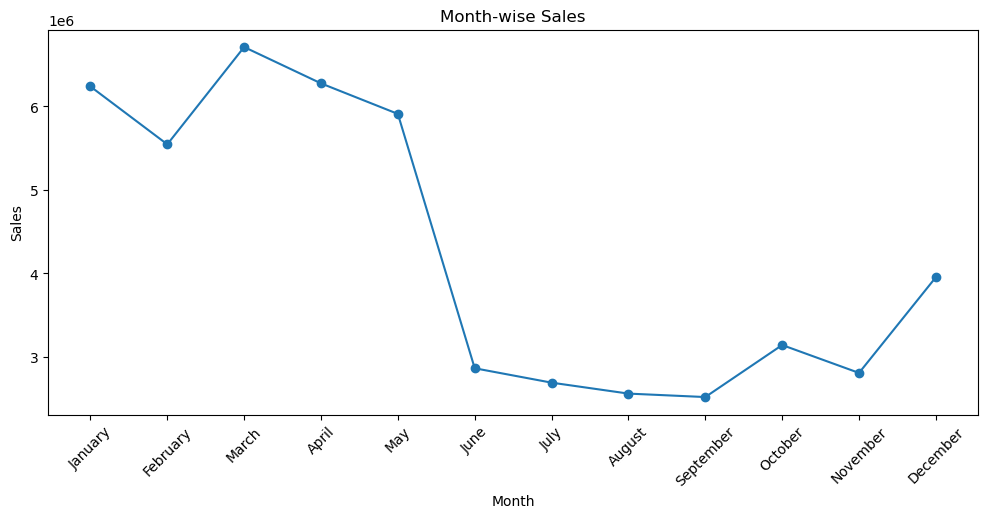

In [15]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [16]:
#4. City-wise Sales

city_names = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

df["City"] = df["City"].replace(city_names)

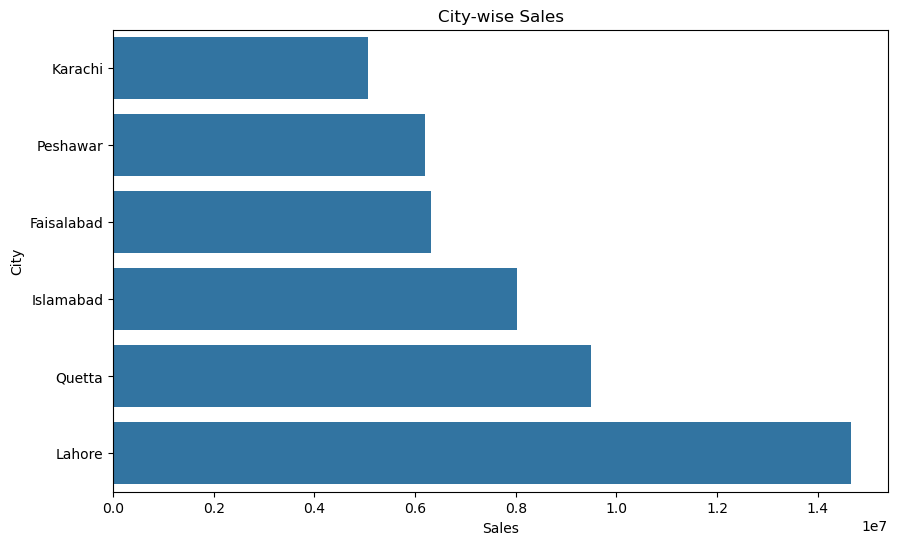

In [17]:
city_sales = df.groupby("City")["total"].sum().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(x=city_sales.values, y=city_sales.index)

plt.title("City-wise Sales")
plt.xlabel("Sales")
plt.ylabel("City")

plt.show()

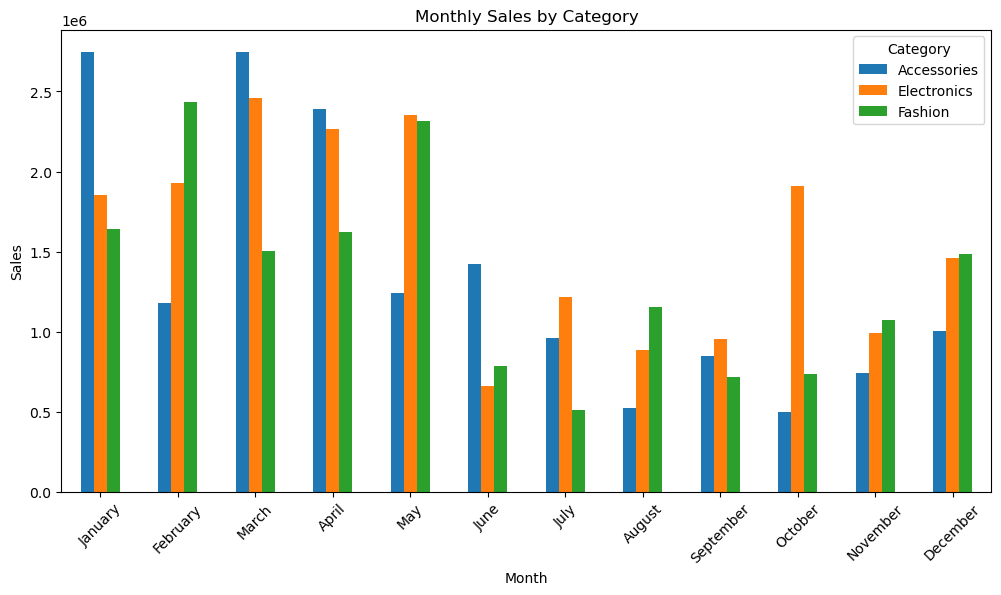

In [18]:
#5. Monthly Sales by Category

category_sales = df.groupby(["Month", "category"])["total"].sum().unstack()

category_sales = category_sales.reindex(month_order)

category_sales.plot(kind="bar", figsize=(12,6))

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.legend(title="Category")

plt.show()